# 00 — First Look at the H&M Dataset

Goal of this notebook: load the three core CSVs, check shapes, dtypes and date ranges, and produce a one-page mental model of the dataset.

**Do not model anything here.** This notebook is purely descriptive.

In [1]:
import sys
from pathlib import Path

# Make `src` importable from the notebook
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt

from src.data.loaders import load_articles, load_customers, load_transactions
from src import config

pd.set_option('display.max_columns', 50)

## 1. Articles (product catalogue)

In [2]:
articles = load_articles()
print('Shape:', articles.shape)
articles.head()

Shape: (105542, 25)


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,0108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,4,Dark,5,Black,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,0108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,3,Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,0108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,1,Dusty Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,0110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,4,Dark,5,Black,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,0110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,3,Light,9,White,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [3]:
# Top product groups
articles['product_group_name'].value_counts().head(10)

product_group_name
Garment Upper body    42741
Garment Lower body    19812
Garment Full body     13292
Accessories           11158
Underwear              5490
Shoes                  5283
Swimwear               3127
Socks & Tights         2442
Nightwear              1899
Unknown                 121
Name: count, dtype: int64

## 2. Customers

In [4]:
customers = load_customers()
print('Shape:', customers.shape)
customers.head()

Shape: (1371980, 7)


,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


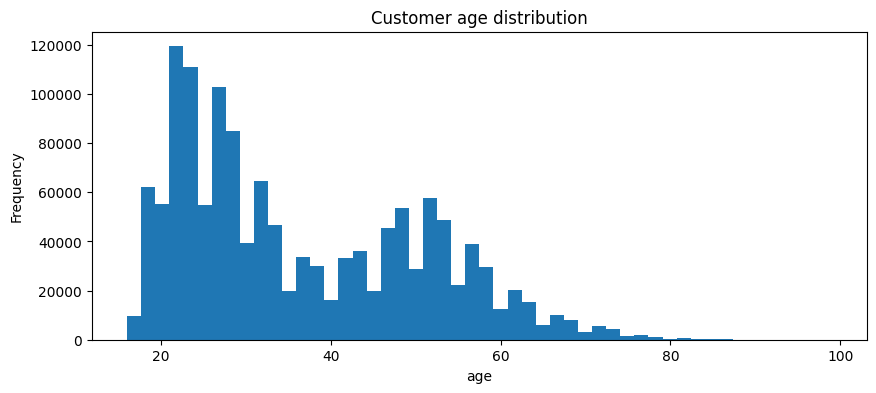

In [5]:
# Age distribution
customers['age'].plot(kind='hist', bins=50, figsize=(10, 4), title='Customer age distribution')
plt.xlabel('age')
plt.show()

## 3. Transactions (sample first to keep it light)

In [6]:
# Load only 1M rows to start — full file has ~31M
transactions = load_transactions(nrows=1_000_000)
print('Shape:', transactions.shape)
print('Date range:', transactions['t_dat'].min(), '→', transactions['t_dat'].max())
transactions.head()

Shape: (1000000, 5)
Date range: 2018-09-20 00:00:00 → 2018-10-11 00:00:00


,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0685687004,0.016932,2


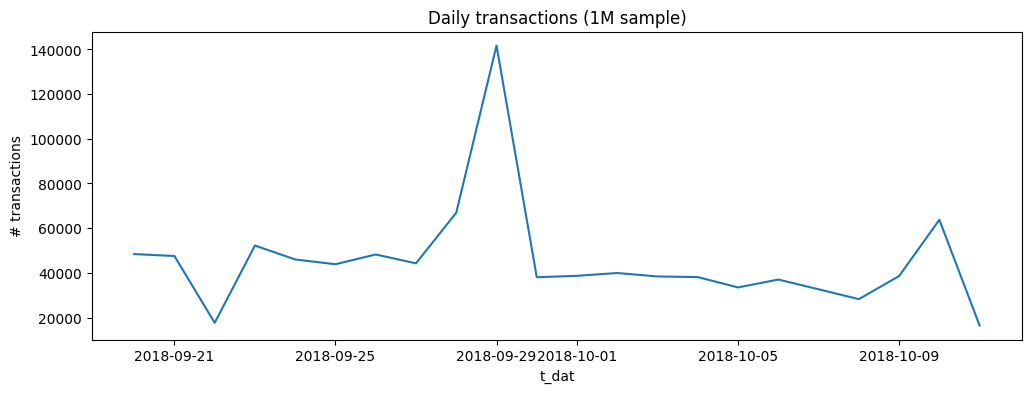

In [7]:
# Daily transaction volume (sample)
transactions.groupby(transactions['t_dat'].dt.date).size().plot(
    figsize=(12, 4), title='Daily transactions (1M sample)'
)
plt.ylabel('# transactions')
plt.show()

## 4. Quick sanity checks

Things to confirm before moving on:
- [ok] Articles file has ~105K rows
- [ok] Customers file has ~1.3M rows
- [ ] Transactions full file covers Sept 2018 → Sept 2020
- [ok] All article_ids in transactions exist in articles
- [ok] All customer_ids in transactions exist in customers

In [8]:
# Referential integrity check on the sample
missing_articles = set(transactions['article_id']) - set(articles['article_id'])
missing_customers = set(transactions['customer_id']) - set(customers['customer_id'])
print(f'Articles not in catalogue: {len(missing_articles)}')
print(f'Customers not in master:   {len(missing_customers)}')

Articles not in catalogue: 0
Customers not in master:   0


In [9]:
# Confirmar el rango temporal completo (no solo el sample)
import pandas as pd
from src.config import TRANSACTIONS_FILE

# Solo cargamos la columna de fecha → muy rápido
dates = pd.read_csv(TRANSACTIONS_FILE, usecols=['t_dat'], parse_dates=['t_dat'])
print(f'Total transactions: {len(dates):,}')
print(f'Date range: {dates["t_dat"].min()} → {dates["t_dat"].max()}')
print(f'Days covered: {(dates["t_dat"].max() - dates["t_dat"].min()).days}')

Total transactions: 31,788,324
Date range: 2018-09-20 00:00:00 → 2020-09-22 00:00:00
Days covered: 733


In [10]:
# Confirmar el rango temporal completo (no solo el sample)
import pandas as pd
from src.config import TRANSACTIONS_FILE

# Solo cargamos la columna de fecha → muy rápido
dates = pd.read_csv(TRANSACTIONS_FILE, usecols=['t_dat'], parse_dates=['t_dat'])
print(f'Total transactions: {len(dates):,}')
print(f'Date range: {dates["t_dat"].min()} → {dates["t_dat"].max()}')
print(f'Days covered: {(dates["t_dat"].max() - dates["t_dat"].min()).days}')

Total transactions: 31,788,324
Date range: 2018-09-20 00:00:00 → 2020-09-22 00:00:00
Days covered: 733
